In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import os

# -----------------------------------------------------------------------------
# Data file
# -----------------------------------------------------------------------------
# The workbook name and location are fixed.
root_dir = os.path.abspath("../..")

CASE_ID = "C0003"

data_file = os.path.join(root_dir, "data", CASE_ID, 'C0003R02_PARK25_LC_1D_SCAN.xlsx')
sheet_name = 'Parameter scan'

data = pd.read_excel(data_file, sheet_name=sheet_name)

print(f'Data file: {data_file}')
print(f'Number of scan cases: {len(data)}')
data.head() # display the first five rows as a demo

Data file: d:\Workspace\eBATS\data\C0003\C0003R02_PARK25_LC_1D_SCAN.xlsx
Number of scan cases: 480


,m_dot_total_kg_s,T_water_in_C,Dh_mm,num_parallel_channels,u_water_m_s,Re_water,P_pump,E_pump_cumulative,m_plate_kg,m_coolant_kg,...,cruise_recovery_Tmax_C,Twater_out_cruise_end_C,dTmax_takeoff_C,dTmax_climb_C,dTmax_transition1_C,dTmax_cruise_C,dTmax_transition2_C,dTmax_descent_C,dTmax_hover_C,dTmax_landing_C
0,0.045,20,3,28,0.227773,681.005631,0.043278,83.094256,2.579877,0.081838,...,1.052304,20.462827,0.412637,1.417092,0.643737,-1.052304,-0.652175,0.526984,10.810119,0.280811
1,0.045,20,4,28,0.128122,510.754223,0.013694,26.291542,2.806896,0.145490,...,1.055711,20.462682,0.412596,1.416093,0.635834,-1.055711,-0.650525,0.527268,10.781822,0.279220
2,0.045,20,5,28,0.081998,408.603378,0.005609,10.769016,2.984378,0.227328,...,1.057705,20.462594,0.412571,1.415490,0.631051,-1.057705,-0.649529,0.527440,10.764693,0.278258
3,0.045,20,6,28,0.056943,340.502815,0.002705,5.193391,3.112323,0.327352,...,1.059014,20.462536,0.412554,1.415086,0.627845,-1.059014,-0.648862,0.527556,10.753211,0.277613
4,0.045,20,3,24,0.265735,794.506569,0.050491,96.943298,2.611723,0.070147,...,0.996352,20.464852,0.413169,1.429751,0.743456,-0.996352,-0.673327,0.523339,11.166119,0.300911


In [3]:
# Select the columns required for the thermal-performance analysis.
plot_data = data[
    [
        'm_dot_total_kg_s',
        'T_water_in_C',
        'Dh_mm',
        'num_parallel_channels',
        'Tmax_mission_C',
        'DeltaT_mission_max_C',
        'P_pump',
        'm_plate_kg',
        'm_coolant_kg',
        'mtotal',
    ]
].copy()

# Convert the plotting columns to numeric values.
for column in plot_data.columns:
    plot_data[column] = pd.to_numeric(plot_data[column], errors='raise')

plot_data.head()


,m_dot_total_kg_s,T_water_in_C,Dh_mm,num_parallel_channels,Tmax_mission_C,DeltaT_mission_max_C,P_pump,m_plate_kg,m_coolant_kg,mtotal
0,0.045,20,3,28,32.386900,2.202147,0.043278,2.579877,0.081838,2.661715
1,0.045,20,4,28,32.346597,2.228296,0.013694,2.806896,0.145490,2.952386
2,0.045,20,5,28,32.322269,2.244249,0.005609,2.984378,0.227328,3.211706
3,0.045,20,6,28,32.305988,2.254997,0.002705,3.112323,0.327352,3.439675
4,0.045,20,3,24,32.907066,1.894854,0.050491,2.611723,0.070147,2.681870


In [4]:
def label_fmt(x):
    s = f"{x:.2f}"
    # if s.endswith("0"):
        # s = f"{x:0.0f}"
    # return rf"{s} \%" if plt.rcParams["text.usetex"] else f"{s} %"
    return s

24 rows for num_parallel_channels = 12
24 rows for num_parallel_channels = 16
24 rows for num_parallel_channels = 20
24 rows for num_parallel_channels = 24
24 rows for num_parallel_channels = 28


<Figure size 1600x300 with 0 Axes>

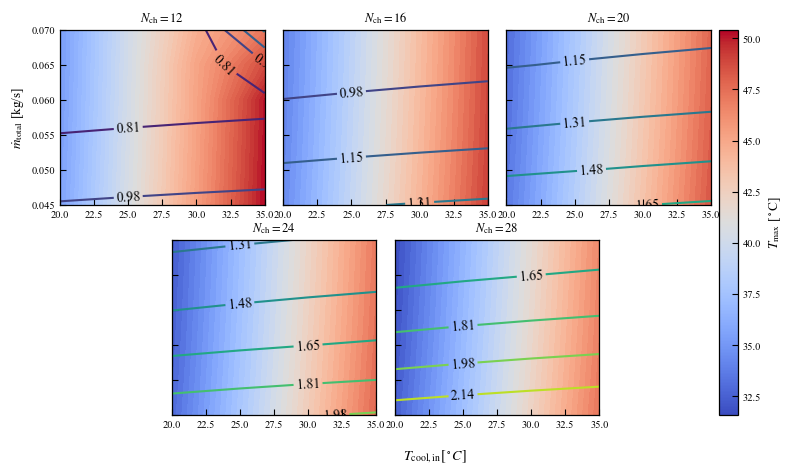

In [5]:
# plot the maximum temperature at varying mass flow rate and inlet temperature for D_h = 4.0 mm

# plot a figure with five sub-figures
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib import ticker
import numpy as np
from scipy.interpolate import griddata


# Apply the same scientific plotting style as the air-cooling figures.
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': 8.5,
    'axes.labelsize': 9.5,
    'axes.titlesize': 9.0,
    'xtick.labelsize': 7.5,
    'ytick.labelsize': 7.5,
    'axes.linewidth': 0.9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'axes.unicode_minus': False,
})
# Create a mosaic where each plot is two entries wide.  Dots represent spaces.
mosaic = """AABBCC
            .DDEE."""

fig = plt.figure(figsize=(16, 3))
# cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("coolwarm", as_cmap=True), norm=plt.Normalize(vmin=T_min, vmax=T_max)))

D_h_selected = 4.0 

thermal_data = data[data['Dh_mm'] == D_h_selected]

thermal_data.head()

key_N_ch = "num_parallel_channels"
key_x = "T_water_in_C"
key_y = "m_dot_total_kg_s"
key_val_T = "Tmax_mission_C"
key_val_dT = "DeltaT_mission_max_C"

N_ch_array = np.sort(thermal_data[key_N_ch].unique())

# locate the maximum and minimum Tmax_mission_C to set the color ruler
T_max, T_min = thermal_data[key_val_T].max(), thermal_data[key_val_T].min()
dT_max, dT_min = thermal_data[key_val_dT].max(), thermal_data[key_val_dT].min()

# use one shared y-axis for all sub-figures
# plt.subplots_adjust(hspace=0.3, wspace=0.3)

fig, ax_dict = plt.subplot_mosaic(mosaic=mosaic, figsize=(10,5))

i = 0
for N_ch in N_ch_array:
    
    ax = ax_dict[chr(65+i)]  # A, B, C, D, E
    thermal_data_N_ch = thermal_data[thermal_data[key_N_ch] == N_ch]
    print(f"{len(thermal_data_N_ch)} rows for {key_N_ch} = {N_ch}")

    # select the subfigure for the current N_ch
    # ax = plt.subplot(1, 5, i + 1)
    
    
    # extract the values and transform them into a 2D array
     
    x_values = sorted(thermal_data_N_ch[key_x].unique())
    y_values = sorted(thermal_data_N_ch[key_y].unique())
    
    # fill in the Z values
    Z_values_T = thermal_data_N_ch.pivot(index=key_y, columns=key_x, values=key_val_T).values

    Z_values_dT = thermal_data_N_ch.pivot(index=key_y, columns=key_x, values=key_val_dT).values
    
    # calculate the space between contours
    contour_spacing = (T_max - T_min) / 10
    
    cmap = sns.color_palette("coolwarm", as_cmap=True)    
    cmap_dT = sns.color_palette("viridis", as_cmap=True)
    levels_dT = np.arange(dT_min, dT_max + (dT_max - dT_min) / 10, (dT_max - dT_min) / 10)
    
    ax.contourf(
        x_values, 
        y_values, 
        Z_values_T, 
        levels=50, 
        cmap=cmap, 
        vmin=T_min, 
        vmax=T_max)

    # display the contour values    
    cs = ax.contour(
        x_values, 
        y_values, 
        Z_values_dT, 
        levels=levels_dT,
        cmap=cmap_dT, 
        vmin=dT_min, 
        vmax=dT_max,
    )
    
    # ax.clabel(cs, cs.levels, fmt=label_fmt, fontsize=7)
    
    ax.clabel(cs, inline=True, fontsize=10, fmt=label_fmt, colors='black')
   
    # hide y-axis for subfigures 2-5
    if i != 0:
        ax.set_yticklabels([])
    else:
        ax.set_ylabel(r"$\dot{m}_\mathrm{total}$ [kg/s]")
    
    
    # plot the channel number as the subfigure's title
    ax.set_title(rf"$N_\mathrm{{ch}}={N_ch}$")
    
    # if i == 4:        
    #     plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=T_min, vmax=T_max)), cax=ax)
    
    # if i == 4:
    #     cbar = plt.colorbar(
    #         plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=T_min, vmax=T_max)),
    #         ax=ax,            
    #     )
    i += 1
    
# use one shared x-axis label
# fig.supylabel(r"$\dot{m}_\mathrm{total}$ [kg/s]")
fig.supxlabel(r"$T_\mathrm{cool,in} [^\circ C]$")

sm = plt.cm.ScalarMappable(
    cmap=sns.color_palette("coolwarm", as_cmap=True),
    norm=Normalize(vmin=T_min, vmax=T_max),
)
sm.set_array([])

fig.colorbar(sm, ax=fig.axes, label=r"$T_{\max}$ [$^\circ$C]", pad=0.01)



Tmax: 50.40356777874079 at mdot=0.045, Tin=35, N_ch=12
Tmin: 31.59042690993439 at mdot=0.07, Tin=20, N_ch=28
24 rows for num_parallel_channels = 12
24 rows for num_parallel_channels = 20
24 rows for num_parallel_channels = 28


<Figure size 1200x400 with 0 Axes>

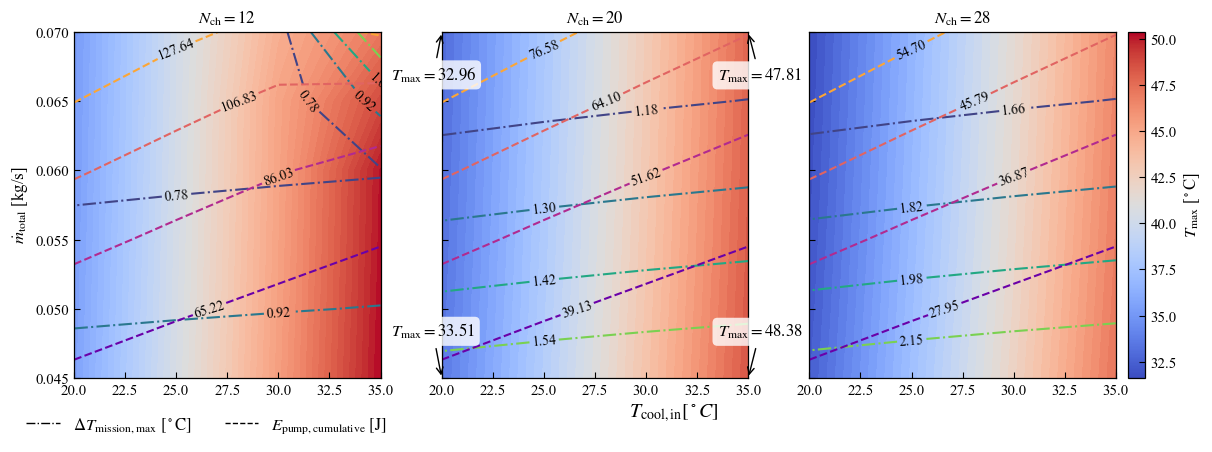

In [132]:
# plot the maximum temperature at varying mass flow rate and inlet temperature for D_h = 4.0 mm

# plot a figure with five sub-figures
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

base_fontsize = 12

# Apply the same scientific plotting style as the air-cooling figures.
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': base_fontsize,
    'axes.labelsize': base_fontsize,
    'axes.titlesize': base_fontsize,
    'xtick.labelsize': base_fontsize * 0.9,
    'ytick.labelsize': base_fontsize * 0.9,
    'axes.linewidth': 0.9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'axes.unicode_minus': False,
})

fig = plt.figure(figsize=(12, 4))
# cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("coolwarm", as_cmap=True), norm=plt.Normalize(vmin=T_min, vmax=T_max)))

D_h_selected = 4.0 

thermal_data = data[data['Dh_mm'] == D_h_selected]

thermal_data.head()

key_N_ch = "num_parallel_channels"
key_x = "T_water_in_C"
key_y = "m_dot_total_kg_s"
key_val_T = "Tmax_mission_C"
key_val_dT = "DeltaT_mission_max_C"
key_val_E = "E_pump_cumulative"

N_ch_array = [12, 20, 28]

# locate the global maximum and minimum Tmax_mission_C to set the color ruler
T_max, T_min = thermal_data[key_val_T].max(), thermal_data[key_val_T].min()

# locate the row of the T_max and T_min
T_max_row = thermal_data[thermal_data[key_val_T] == T_max]
T_min_row = thermal_data[thermal_data[key_val_T] == T_min]

mdot_Tmax, Tin_Tmax, N_ch_Tmax = T_max_row[key_y].values[0], T_max_row[key_x].values[0], T_max_row[key_N_ch].values[0]
mdot_Tmin, Tin_Tmin, N_ch_Tmin = T_min_row[key_y].values[0], T_min_row[key_x].values[0], T_min_row[key_N_ch].values[0]

print(f"Tmax: {T_max} at mdot={mdot_Tmax}, Tin={Tin_Tmax}, N_ch={N_ch_Tmax}")
print(f"Tmin: {T_min} at mdot={mdot_Tmin}, Tin={Tin_Tmin}, N_ch={N_ch_Tmin}")

# use one shared y-axis for all sub-figures
# plt.subplots_adjust(hspace=0.3, wspace=0.3)

fig, ax_dict = plt.subplots(1, 3, figsize=(16, 4.5))  # Adjust the number of subplots as needed

i = 0
for N_ch in N_ch_array:
    
    ax = ax_dict[i]
    thermal_data_N_ch = thermal_data[thermal_data[key_N_ch] == N_ch]
    print(f"{len(thermal_data_N_ch)} rows for {key_N_ch} = {N_ch}")

    # select the subfigure for the current N_ch
    # ax = plt.subplot(1, 5, i + 1)
    
    
    # extract the values and transform them into a 2D array     
    x_values = sorted(thermal_data_N_ch[key_x].unique())
    y_values = sorted(thermal_data_N_ch[key_y].unique())
    
    # fill in the Z values
    Z_values_T = thermal_data_N_ch.pivot(index=key_y, columns=key_x, values=key_val_T).values    
    
    Z_values_dT = thermal_data_N_ch.pivot(index=key_y, columns=key_x, values=key_val_dT).values
    
    Z_values_E = thermal_data_N_ch.pivot(index=key_y, columns=key_x, values=key_val_E).values
    
    # local min, max of temperature difference and pump energy    
    # T_max_h, T_max_l = Z_values_T.max(), Z_values_T.min()
    dT_max, dT_min = Z_values_dT.max(), Z_values_dT.min()
    E_max, E_min = Z_values_E.max(), Z_values_E.min()
    
    # extract the T_max and the first column of the Z_values_T
    Z_values_T_left = Z_values_T[:, 0]
    T_max_h_left = Z_values_T_left.max()
    T_max_l_left = Z_values_T_left.min()
    
    Z_values_T_right = Z_values_T[:, -1]
    T_max_h_right = Z_values_T_right.max()
    T_max_l_right = Z_values_T_right.min()
    
    # calculate the space between contours  
    cmap = sns.color_palette("coolwarm", as_cmap=True)    
    
    ax.contourf(
        x_values, 
        y_values, 
        Z_values_T, 
        levels=50, 
        cmap=cmap, 
        vmin=T_min, 
        vmax=T_max)

    cmap_dT = sns.color_palette("viridis", as_cmap=True)
    space_num = 5
    levels_dT = np.arange(dT_min, dT_max + (dT_max - dT_min) / space_num, (dT_max - dT_min) / space_num)
    # display the contour values    
    cs = ax.contour(
        x_values, 
        y_values, 
        Z_values_dT, 
        levels=levels_dT,
        cmap=cmap_dT, 
        vmin=dT_min, 
        vmax=dT_max,
        linestyles='dashdot'
    )
    
    cmap_E = sns.color_palette("plasma", as_cmap=True)
    space_num_E = 5
    levels_E = np.arange(E_min, E_max + (E_max - E_min) / space_num_E, (E_max - E_min) / space_num_E)
    # display the contour values    
    cs_E = ax.contour(
        x_values, 
        y_values, 
        Z_values_E,
        levels=levels_E,
        cmap=cmap_E,
        vmin=E_min, 
        vmax=E_max,
        linestyles='dashed'
    )
    
    # ax.clabel(cs, cs.levels, fmt=label_fmt, fontsize=7)
   
    # if N_ch == 12:
    #     # annotate the global maximum
    #     ax.annotate(
    #         f"Tmax={T_max:.2f}",
    #         xy=(Tin_Tmax, mdot_Tmax),
    #         xytext=(Tin_Tmax - 0.9, mdot_Tmax + 0.005),
    #         arrowprops=dict(facecolor='black', shrink=0.05),
    #         fontsize=8,
    #     )
    
    # if N_ch == 28:
    #     # annotate the global minimum
    #     ax.annotate(
    #         f"Tmin={T_min:.2f}",
    #         xy=(Tin_Tmin, mdot_Tmin),
    #         xytext=(Tin_Tmin + 1, mdot_Tmin - 0.005),
    #         arrowprops=dict(facecolor='black', shrink=0.05),
    #         fontsize=8,
    #     )
    
    if N_ch == 20:
        # annotate the T_max at the four corners of the subfigure for illustration purpose
        ax.annotate(
            fr"$T_\mathrm{{max}}={T_max_l_left:.2f}$",
            xy=(x_values[0], y_values[-1]),
            xytext=(x_values[0]-2.5, y_values[-1]-0.0035),
            arrowprops=dict(arrowstyle='->', facecolor='black'),
            fontsize=base_fontsize,
            bbox=dict(boxstyle='round,pad=0.3', edgecolor='none', facecolor='white', alpha=0.8),            
        )
        ax.annotate(
            fr"$T_\mathrm{{max}}={T_max_h_left:.2f}$",
            xy=(x_values[0], y_values[0]),
            xytext=(x_values[0]-2.5, y_values[0] + 0.003),
            arrowprops=dict(arrowstyle='->', facecolor='black'),
            fontsize=base_fontsize,
            bbox=dict(boxstyle='round,pad=0.3', edgecolor='none', facecolor='white', alpha=0.8),            

        )
        ax.annotate(
            fr"$T_\mathrm{{max}}={T_max_l_right:.2f}$",
            xy=(x_values[-1], y_values[-1]),
            xytext=(x_values[-1]-1.5, y_values[-1] - 0.0035),
            arrowprops=dict(arrowstyle='->', facecolor='black'),
            fontsize=base_fontsize,
            bbox=dict(boxstyle='round,pad=0.3', edgecolor='none', facecolor='white', alpha=0.8),            
        )
        ax.annotate(
            fr"$T_\mathrm{{max}}={T_max_h_right:.2f}$",
            xy=(x_values[-1], y_values[0]),
            xytext=(x_values[-1]-1.5, y_values[0] + 0.003),
            arrowprops=dict(arrowstyle='->', facecolor='black'),
            fontsize=base_fontsize,
            bbox=dict(boxstyle='round,pad=0.3', edgecolor='none', facecolor='white', alpha=0.8),            
        )

     
    ax.clabel(cs, inline=True, fontsize=10, fmt=label_fmt, colors='black')
    
    ax.clabel(cs_E, inline=True, fontsize=10, fmt=label_fmt, colors='black')
   
    # hide y-axis for subfigures 2-5
    if i != 0:
        ax.set_yticklabels([])
    else:
        ax.set_ylabel(r"$\dot{m}_\mathrm{total}$ [kg/s]")
    
    
    # plot the channel number as the subfigure's title
    ax.set_title(rf"$N_\mathrm{{ch}}={N_ch}$")
    
    # if i == 4:        
    #     plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=T_min, vmax=T_max)), cax=ax)
    
    # if i == 4:
    #     cbar = plt.colorbar(
    #         plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=T_min, vmax=T_max)),
    #         ax=ax,            
    #     )
    i += 1
    
# use one shared x-axis label
# fig.supylabel(r"$\dot{m}_\mathrm{total}$ [kg/s]")
fig.supxlabel(r"$T_\mathrm{cool,in} [^\circ C]$")

# Add a legend for the contour lines
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', lw=1, linestyle='dashdot', label=r'$\Delta T_\mathrm{mission,max}~[\mathrm{^\circ C}]$'),
    Line2D([0], [0], color='black', lw=1, linestyle='dashed', label=r'$E_\mathrm{pump,cumulative}~[\mathrm{J}]$'),
]
# Adjust the legend position and font size as needed

fig.legend(handles=legend_elements, loc='lower right', ncol=2, fontsize=base_fontsize, frameon=False, bbox_to_anchor=(0.33, -0.05))


sm = plt.cm.ScalarMappable(
    cmap=sns.color_palette("coolwarm", as_cmap=True),
    norm=Normalize(vmin=T_min, vmax=T_max),
)
sm.set_array([])

fig.colorbar(sm, ax=fig.axes, label=r"$T_{\max}$ [$^\circ$C]", pad=0.01)

# save the figure to a specified output folder (for paper drafting)

output_folder = r"D:\Workspace\Paper_eBATS\images" # the working directory of the paper draft

import os
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    
# overwrite the file
fig.savefig(os.path.join(output_folder, "Tmax_dT_LC_BTMS_scan.png"), dpi=300, bbox_inches='tight')
# plt.close()


Emax: 148.4444255558878 at mdot=0.07, Tin=20, N_ch=12
Emin: 19.03564715845082 at mdot=0.045, Tin=35, N_ch=28
24 rows for num_parallel_channels = 12
24 rows for num_parallel_channels = 20
24 rows for num_parallel_channels = 28


<Figure size 1200x400 with 0 Axes>

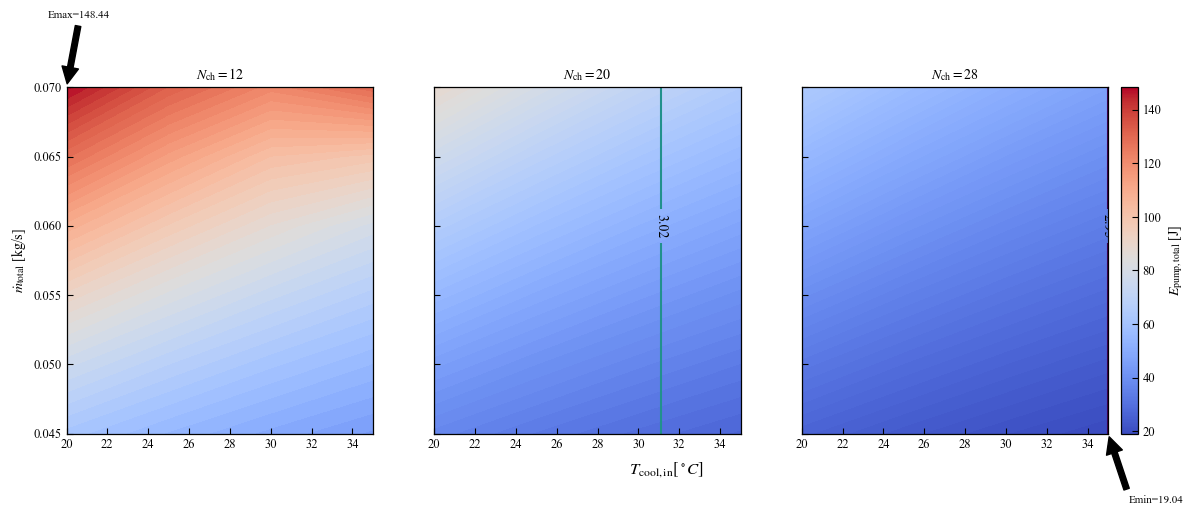

In [11]:
# plot the total energy consumption at varying mass flow rate and inlet temperature for D_h = 4.0 mm

# plot a figure with five sub-figures
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

base_fontsize = 10

# Apply the same scientific plotting style as the air-cooling figures.
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': base_fontsize,
    'axes.labelsize': base_fontsize,
    'axes.titlesize': base_fontsize,
    'xtick.labelsize': base_fontsize * 0.9,
    'ytick.labelsize': base_fontsize * 0.9,
    'axes.linewidth': 0.9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'axes.unicode_minus': False,
})

fig = plt.figure(figsize=(12, 4))
# cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("coolwarm", as_cmap=True), norm=plt.Normalize(vmin=T_min, vmax=T_max)))

D_h_selected = 4.0 

thermal_data = data[data['Dh_mm'] == D_h_selected]

thermal_data.head()

key_N_ch = "num_parallel_channels"
key_x = "T_water_in_C"
key_y = "m_dot_total_kg_s"
key_val_E = "E_pump_cumulative"
key_val_mass = "mtotal"

N_ch_array = [12, 20, 28]

# locate the maximum and minimum Tmax_mission_C to set the color ruler
E_max, E_min = thermal_data[key_val_E].max(), thermal_data[key_val_E].min()

# locate the row of the T_max and T_min
E_max_row = thermal_data[thermal_data[key_val_E] == E_max]
E_min_row = thermal_data[thermal_data[key_val_E] == E_min]

mdot_Emax, Tin_Emax, N_ch_Emax = E_max_row[key_y].values[0], E_max_row[key_x].values[0], E_max_row[key_N_ch].values[0]
mdot_Emin, Tin_Emin, N_ch_Emin = E_min_row[key_y].values[0], E_min_row[key_x].values[0], E_min_row[key_N_ch].values[0]

print(f"Emax: {E_max} at mdot={mdot_Emax}, Tin={Tin_Emax}, N_ch={N_ch_Emax}")
print(f"Emin: {E_min} at mdot={mdot_Emin}, Tin={Tin_Emin}, N_ch={N_ch_Emin}")

mass_max, mass_min = thermal_data[key_val_mass].max(), thermal_data[key_val_mass].min()

# use one shared y-axis for all sub-figures
# plt.subplots_adjust(hspace=0.3, wspace=0.3)

fig, ax_dict = plt.subplots(1, 3, figsize=(16, 4.5))  # Adjust the number of subplots as needed

i = 0
for N_ch in N_ch_array:
    
    ax = ax_dict[i]
    thermal_data_N_ch = thermal_data[thermal_data[key_N_ch] == N_ch]
    print(f"{len(thermal_data_N_ch)} rows for {key_N_ch} = {N_ch}")

    # select the subfigure for the current N_ch
    # ax = plt.subplot(1, 5, i + 1)
    
    
    # extract the values and transform them into a 2D array     
    x_values = sorted(thermal_data_N_ch[key_x].unique())
    y_values = sorted(thermal_data_N_ch[key_y].unique())
    
    # fill in the Z values
    Z_values_E = thermal_data_N_ch.pivot(index=key_y, columns=key_x, values=key_val_E).values

    Z_values_mass = thermal_data_N_ch.pivot(index=key_y, columns=key_x, values=key_val_mass).values
    
    # calculate the space between contours
    contour_spacing = (E_max - E_min) / 10
    
    cmap = sns.color_palette("coolwarm", as_cmap=True)    
    cmap_mass = sns.color_palette("viridis", as_cmap=True)
    space_num = 10
    levels_mass = np.arange(mass_min, mass_max + (mass_max - mass_min) / space_num, (mass_max - mass_min) / space_num)
    
    ax.contourf(
        x_values, 
        y_values, 
        Z_values_E, 
        levels=50, 
        cmap=cmap, 
        vmin=E_min, 
        vmax=E_max)

    # display the contour values    
    cs = ax.contour(
        x_values, 
        y_values, 
        Z_values_mass, 
        levels=levels_mass,
        cmap=cmap_mass, 
        vmin=mass_min, 
        vmax=mass_max,
    )
    
    # ax.clabel(cs, cs.levels, fmt=label_fmt, fontsize=7)
   
    if N_ch == 12:
        # annotate the global maximum
        ax.annotate(
            f"Emax={E_max:.2f}",
            xy=(Tin_Emax, mdot_Emax),
            xytext=(Tin_Emax - 0.9, mdot_Emax + 0.005),
            arrowprops=dict(facecolor='black', shrink=0.05),
            fontsize=8,
        )
    
    if N_ch == 28:
        # annotate the global minimum
        ax.annotate(
            f"Emin={E_min:.2f}",
            xy=(Tin_Emin, mdot_Emin),
            xytext=(Tin_Emin + 1, mdot_Emin - 0.005),
            arrowprops=dict(facecolor='black', shrink=0.05),
            fontsize=8,
        )
     
    ax.clabel(cs, inline=True, fontsize=10, fmt="%1.2f", colors='black')
   
    # hide y-axis for subfigures 2-5
    if i != 0:
        ax.set_yticklabels([])
    else:
        ax.set_ylabel(r"$\dot{m}_\mathrm{total}$ [kg/s]")
    
    
    # plot the channel number as the subfigure's title
    ax.set_title(rf"$N_\mathrm{{ch}}={N_ch}$")
    
    # if i == 4:        
    #     plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=T_min, vmax=T_max)), cax=ax)
    
    # if i == 4:
    #     cbar = plt.colorbar(
    #         plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=E_min, vmax=E_max)),
    #         ax=ax,            
    #     )
    i += 1
    
# use one shared x-axis label
# fig.supylabel(r"$\dot{m}_\mathrm{total}$ [kg/s]")
fig.supxlabel(r"$T_\mathrm{cool,in} [^\circ C]$")

sm = plt.cm.ScalarMappable(
    cmap=sns.color_palette("coolwarm", as_cmap=True),
    norm=Normalize(vmin=E_min, vmax=E_max),
)
sm.set_array([])

fig.colorbar(sm, ax=fig.axes, label=r"$E_{\mathrm{pump,total}}$ [J]", pad=0.01)

# save the figure to a specified output folder (for paper drafting)

output_folder = r"D:\Workspace\Paper_eBATS\images" # the working directory of the paper draft

import os
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    
# overwrite the file
fig.savefig(os.path.join(output_folder, "E_pump_mass_LC_BTMS_scan.png"), dpi=300, bbox_inches='tight')
# plt.close()
